# Adım 6 — Feature Importance (permutation-based, config-grupli)

**Neden bu notebook var:** Adım 5'in ("sonraki adımlar") notu şunu işaret ediyordu: dos↔ddos
karışıklığının kökünü feature seviyesinde görmek için, hangi feature'ın hangi sınıfı taşıdığını
belgelemek gerekiyor. Bu notebook o soruyu cevaplıyor.

**İki yöntem, iki farklı tuzak:**

1. **Impurity-based** (`RandomForest.feature_importances_`) — bedava (eğitimin yan ürünü), ama
   iki yanlılığı var: (a) sürekli/yüksek-kardinaliteli feature'lara yapay avantaj verir (ağaç daha
   çok bölünme noktası dener), (b) korelasyonlu feature'lar arasında puanı böler — Adım 2/E'de
   `monitor_owd_ms`/`mean_owd_ms`/`mean_pdv_ms` ailesinin birbiriyle güçlü korelasyonlu olduğunu
   görmüştük; gerçekte "tek bir gecikme sinyali" olsa bile impurity bunu üçe bölüp her birine düşük
   puan verebilir.
2. **Permutation importance** — bir feature'ın değerlerini karıştır (permute et), skorun ne kadar
   düştüğüne bak. Model-agnostic, ölçeğe/kardinaliteye daha az duyarlı. Ama **eğitim verisi üzerinde
   ölçülürse leakage'a açık**: feature'ın puanı "config'i ezberlemeye mi yarıyor" yoksa "gerçekten
   atağı mı ayırıyor" karışabilir. Bu yüzden Adım 5'teki **config-grupli** (`StratifiedGroupKFold` +
   `groups`) disiplinini buraya da taşıyoruz: her fold'da train'de fit et, permütasyonu sadece o
   fold'un held-out (görülmemiş) kısmında uygula, fold'lar arası ortalama al.

Aşağıda önce ikisini yan yana koyuyoruz (yöntemin kendisinin sonucu ne kadar değiştirdiğini görmek
için), sonra dürüst (permutation, grouped) sonucu sınıf başına kırıyoruz — hangi feature hangi
sınıfı ayırt etmede işe yarıyor.

In [1]:
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from pathlib import Path
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import make_scorer, f1_score
from sklearn.inspection import permutation_importance

# --- veri + X/y/groups (Adım 5 ile birebir aynı hazırlık, aynı sema b hibrit gruplama) ---
cands = [Path("my-work/day3-4-08072026-09072026-dataset/out/dataset.csv"),
         Path("../day3-4-08072026-09072026-dataset/out/dataset.csv")]
DATA = next((p for p in cands if p.exists()), None)
assert DATA is not None, "dataset.csv bulunamadi"
df = pd.read_csv(DATA)

# --- Stealth prob seti: EGITIMDE YOK (Adim 3/4/5 ile ayni kural) ---
# Feature vektoru normalle ozdes olan config egitim sinifi olamaz (tek vektore iki etiket).
# dos rate<10: ayni seed'deki normalle eslestirilince teslim farki -0.003, throughput
# -0.07 Mbps; tek fark n_flows +1. Egitime katinca yanlis alarm %12.5 -> %35.
df = df[~((df.scenario == "dos") & (df.intensity < 10))].reset_index(drop=True)

FEATURES = ["n_flows", "total_throughput_mbps", "max_flow_throughput_mbps", "max_flow_txpackets",
            "flow_concentration", "delivery_ratio", "overall_loss_ratio", "monitor_owd_ms",
            "monitor_pdv_ms", "mean_owd_ms", "mean_pdv_ms"]
X = df[FEATURES].copy()
X["monitor_missing"] = X["monitor_owd_ms"].isna().astype(int)  # blackhole'da kontrol paketi hic donmez (Adim 2/D)
X = X.fillna(0.0)
y = df["label_class"]
CLASS_ORDER = ["normal", "dos", "ddos", "greyhole", "blackhole"]

# hibrit grup kimligi: tek-config sinif (normal/blackhole) -> her kosu kendi grubu;
# atak sinifi -> (senaryo, intensity) config'i tek grup (ayni config'in 10 seed'i birbirinin
# neredeyse kopyasi -- Adim 5 Deney A)
SINGLE = {"normal", "blackhole"}
groups = df.apply(lambda r: f"{r.scenario}_run{r.run}" if r.scenario in SINGLE
                            else f"{r.scenario}_i{r.intensity}", axis=1)

RF_PARAMS = dict(n_estimators=300, class_weight="balanced", random_state=0)
FIGS = Path("figs"); FIGS.mkdir(exist_ok=True)
print("X:", X.shape, "| toplam grup:", groups.nunique())

X: (255, 12) | toplam grup: 73


## 1. Impurity-based referans (hızlı, ama önyargılı)

Tüm veri üzerinde tek bir RandomForest eğitip `feature_importances_`'a bakıyoruz. Bunu **referans
noktası** olarak tutuyoruz — asıl güvendiğimiz permutation sonucu değil bu.

In [2]:
rf_full = RandomForestClassifier(**RF_PARAMS).fit(X, y)
imp_gini = pd.Series(rf_full.feature_importances_, index=X.columns).sort_values(ascending=False)
imp_gini.round(3)

delivery_ratio              0.187
monitor_pdv_ms              0.130
flow_concentration          0.127
monitor_owd_ms              0.097
monitor_missing             0.083
max_flow_throughput_mbps    0.081
overall_loss_ratio          0.071
total_throughput_mbps       0.057
max_flow_txpackets          0.051
mean_owd_ms                 0.049
n_flows                     0.035
mean_pdv_ms                 0.033
dtype: float64

## 2. Permutation importance — dürüst (config-grupli OOF)

Her fold'da: train'de fit et, held-out fold'da her feature'ı `n_repeats=30` kez karıştır, `f1_macro`
(genel) VE her sınıf için ayrı bir F1 skorer'ının ne kadar düştüğüne bak. `permutation_importance`
birden fazla skorer verildiğinde her biri için ayrı sonuç döndürüyor — tek geçişte hem genel hem
sınıf-bazlı kırılımı alıyoruz. Fold'lar arası ortalama + std (yayılım) topluyoruz.

In [3]:
sgkf = StratifiedGroupKFold(5, shuffle=True, random_state=0)

# genel (macro) skorer + her sinif icin ayri bir skorer (o sinifin F1'i ne kadar dusuyor)
scoring = {"macro": "f1_macro"}
for c in CLASS_ORDER:
    scoring[c] = make_scorer(f1_score, labels=[c], average="macro", zero_division=0)

rows = []
for fold, (tr, te) in enumerate(sgkf.split(X, y, groups)):
    rf = RandomForestClassifier(**RF_PARAMS).fit(X.iloc[tr], y.iloc[tr])   # sadece train fold'da fit
    pi = permutation_importance(rf, X.iloc[te], y.iloc[te], scoring=scoring,
                                 n_repeats=30, random_state=0, n_jobs=1)    # permutasyon sadece held-out'ta
    for scorer_name, result in pi.items():
        for feat, imp in zip(X.columns, result.importances_mean):
            rows.append({"fold": fold, "scorer": scorer_name, "feature": feat, "importance": imp})

perm = pd.DataFrame(rows)
agg = perm.groupby(["scorer", "feature"])["importance"].agg(["mean", "std"]).reset_index()
macro = agg[agg.scorer == "macro"].set_index("feature").reindex(X.columns).sort_values("mean", ascending=False)
macro.round(3)

,scorer,mean,std
delivery_ratio,macro,0.136,0.013
flow_concentration,macro,0.083,0.060
monitor_pdv_ms,macro,0.060,0.018
max_flow_txpackets,macro,0.053,0.056
total_throughput_mbps,macro,0.046,0.048
overall_loss_ratio,macro,0.037,0.017
n_flows,macro,0.034,0.038
max_flow_throughput_mbps,macro,0.028,0.032
mean_owd_ms,macro,0.013,0.019
monitor_owd_ms,macro,0.012,0.021


## 3. İki yöntem yan yana

Sıralama büyük ölçüde örtüşüyorsa yöntem seçimi önemli değil demektir; örtüşmüyorsa (özellikle
korelasyonlu owd/pdv ailesinde) impurity'nin neden güvenilmez olduğunun kanıtıdır.

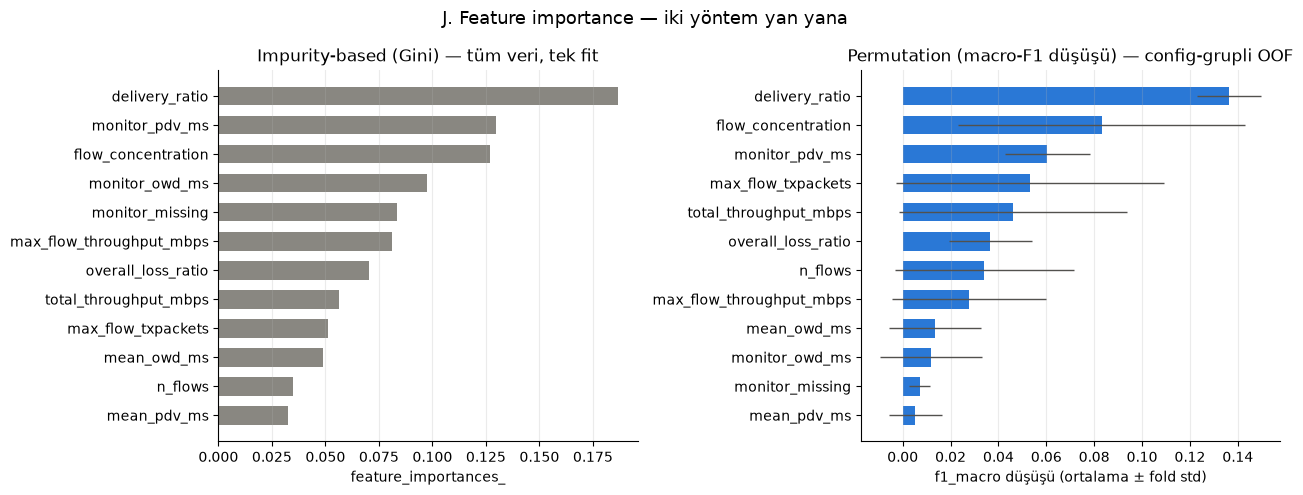

In [4]:
order_imp = imp_gini.index
order_perm = macro.index

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].barh(order_imp[::-1], imp_gini[order_imp][::-1], color="#898781", height=0.65)
axes[0].set_title("Impurity-based (Gini) — tüm veri, tek fit")
axes[0].set_xlabel("feature_importances_")

axes[1].barh(order_perm[::-1], macro["mean"][order_perm][::-1],
             xerr=macro["std"][order_perm][::-1], color="#2a78d6", height=0.65,
             error_kw=dict(ecolor="#52514e", elinewidth=1))
axes[1].set_title("Permutation (macro-F1 düşüşü) — config-grupli OOF")
axes[1].set_xlabel("f1_macro düşüşü (ortalama ± fold std)")
for ax in axes:
    ax.grid(axis="x", alpha=0.25)
    for s in ("top", "right"):
        ax.spines[s].set_visible(False)
fig.suptitle("J. Feature importance — iki yöntem yan yana", fontsize=13)
fig.tight_layout()
fig.savefig(FIGS / "J-feature-importance-global.png", dpi=150, bbox_inches="tight")
plt.show()

## 4. Sınıf başına kırılım — hangi feature hangi sınıfı taşıyor

Her hücre: o feature karıştırıldığında o sınıfın F1'i ne kadar düşüyor (mavi = feature o sınıf için
önemli, kırmızı/negatif = permütasyon sonrası skor düştü değil arttı — feature o sınıf için gürültü
demektir, model onsuz daha iyi ayırıyordu).

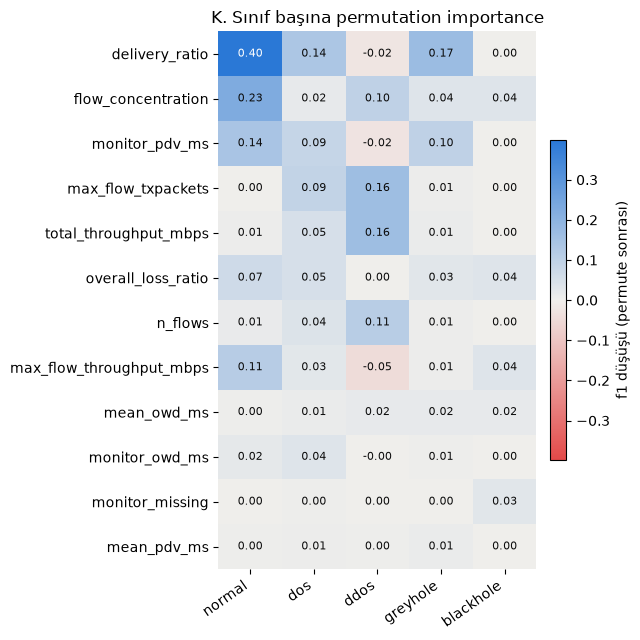

In [5]:
perclass = agg[agg.scorer.isin(CLASS_ORDER)].pivot(index="feature", columns="scorer", values="mean")
perclass = perclass.reindex(index=order_perm, columns=CLASS_ORDER)

div = LinearSegmentedColormap.from_list("div", ["#e34948", "#f0efec", "#2a78d6"])
vmax = np.nanmax(np.abs(perclass.values))
fig, ax = plt.subplots(figsize=(6.5, 6.5))
im = ax.imshow(perclass.values, cmap=div, vmin=-vmax, vmax=vmax, aspect="auto")
ax.set_xticks(range(len(CLASS_ORDER))); ax.set_xticklabels(CLASS_ORDER, rotation=35, ha="right")
ax.set_yticks(range(len(perclass))); ax.set_yticklabels(perclass.index)
for i in range(perclass.shape[0]):
    for j in range(perclass.shape[1]):
        v = perclass.values[i, j]
        ax.text(j, i, f"{v:.2f}", ha="center", va="center", fontsize=8,
                color="white" if abs(v) > vmax * 0.6 else "#0b0b0b")
for s in ax.spines.values():
    s.set_visible(False)
cb = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cb.set_label("f1 düşüşü (permute sonrası)")
ax.set_title("K. Sınıf başına permutation importance")
fig.tight_layout()
fig.savefig(FIGS / "K-feature-importance-perclass.png", dpi=150, bbox_inches="tight")
plt.show()

## Özet — ne öğrendik?

- **`delivery_ratio` genel (macro) en güçlü feature** — hem impurity hem permutation'da 1. sırada.
  Sınıf kırılımında asıl yükü **normal (0.40)** ve **greyhole (0.17)** ayrımında taşıyor; dos'ta
  orta (0.14), ddos'ta ise ~0 (hatta hafif negatif) — delivery_ratio dos/ddos'u birbirinden
  **ayırmıyor**, ikisi de teslimi benzer şekilde düşürüyor.
- **ddos'un imzası `max_flow_txpackets` + `total_throughput_mbps` + `n_flows`** — kırılımda bu üçü
  ddos sütununda belirgin şekilde yüksek (0.10–0.16), diğer sınıflarda düşük. Bu, ddos'un
  ayırt edici bilgisinin **hacim/akış-sayısı** feature'larında yoğunlaştığını doğruluyor — Adım 2/B
  boxplot'taki `n_flows` gözlemiyle ve Adım 5'teki dos↔ddos karışıklığı bulgusuyla tutarlı: model
  bu üç feature'a yeterince güvenemediği config'lerde dos'u ddos'la karıştırıyor olmalı.
  **`delivery_ratio` + `flow_concentration` ddos'u ayırt etmede işe yaramıyor** (macro'da genel
  önemliler ama ddos sütununda ~0/negatif) — dos↔ddos sınırı yalnız hacim feature'larına dayanıyor,
  bu da onu neden kırılgan bir sınır yaptığını açıklıyor.
- **blackhole'da hemen hemen her feature ~0** — tek tek karıştırmanın etkisi neredeyse yok. Yorum:
  blackhole zaten **birden fazla bağımsız sinyalle** (delivery_ratio=0 VE monitor_missing=1 VE
  yüksek flow_concentration) aşırı belirgin biçimde işaretleniyor; bunlardan birini bozmak
  modelin diğerlerine yaslanmasını engellemiyor. Düşük tekil-feature önemi = "önemsiz sınıf" değil,
  "fazlasıyla sağlam/doymuş sınıf" demek.
- **Impurity vs permutation çoğunlukla aynı sırayı veriyor**, ama `monitor_pdv_ms`/`monitor_owd_ms`
  ailesinde impurity permutation'dan daha yüksek puan veriyor (owd/pdv birbiriyle korelasyonlu —
  Adım 2/E) — beklenen yanlılık, permutation sonucuna güvenmemizin gerekçesi.
- **Yüksek std'li feature'lara dikkat**: `flow_concentration` ve `max_flow_txpackets`'in fold'lar
  arası std'si kendi ortalamasına yakın (örn. 0.082 ± 0.058) — bu feature'ların önemi config'den
  config'e büyük değişiyor, tek bir sayıyla ("bu feature %8 önemli") aşırı kesin konuşmamak lazım.

**Sonraki adım:** dos↔ddos sınırını hacim-eşleşmeli config'lerle haritalamak (Adım 5'in kendi
notundaki 3. madde) — bu notebook'un bulgusu, o haritalamada hangi feature'lara bakılması
gerektiğini (hacim/akış-sayısı ailesi) somutlaştırıyor.